In [6]:
from BGN_LNG.Utils.utils_spark import retrieve_credentials, get_access_token, list_contracts

# Input the path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)
# print(access_token)
list_contracts(access_token)

ModuleNotFoundError: No module named 'BGN_LNG'

In [6]:

import os, sys, pprint
print("CWD:", os.getcwd())
print("\nFirst 5 sys.path entries:")
pprint.pp(sys.path[:5])


CWD: C:\Marti\python_tests_2\BGN_LNG\adhoc_scripts

First 5 sys.path entries:
['C:\\Program Files\\JetBrains\\PyCharm '
 '2025.3.1\\plugins\\python-ce\\helpers\\jupyter_debug',
 'C:\\Program Files\\JetBrains\\PyCharm '
 '2025.3.1\\plugins\\python-ce\\helpers\\pydev',
 'C:\\Users\\marti.fernandezreal\\AppData\\Local\\Programs\\Python\\Python314\\python314.zip',
 'C:\\Users\\marti.fernandezreal\\AppData\\Local\\Programs\\Python\\Python314\\DLLs',
 'C:\\Users\\marti.fernandezreal\\AppData\\Local\\Programs\\Python\\Python314\\Lib']


In [22]:
from BGN_LNG.Utils.utils_spark import fetch_freight_prices

spark30_174 = fetch_freight_prices(access_token, "spark30s", 30*30, my_vessel='174-2stroke')
spark30_174

/v1.0/contracts/spark30s/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30s/price-releases/?limit=900


,Release Date,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
0,2025-12-22,spark30s,2026-01-06,92250,95000,90000
1,2025-12-19,spark30s,2026-01-03,92000,95000,90000
2,2025-12-18,spark30s,2026-01-02,98000,105000,90000
3,2025-12-17,spark30s,2026-01-01,97000,105000,85000
4,2025-12-16,spark30s,2025-12-31,100750,105000,85000
...,...,...,...,...,...,...
895,2022-06-09,spark30s,2022-06-24,102500,114750,97000
896,2022-06-08,spark30s,2022-06-23,102500,114750,97000
897,2022-06-07,spark30s,2022-06-22,99500,114750,95000
898,2022-06-06,spark30s,2022-06-21,97000,112750,90000


,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
Release Date,,,,,
2025-12-22,spark30s,2026-01-06,92250,95000,90000
2025-12-19,spark30s,2026-01-03,92000,95000,90000
2025-12-18,spark30s,2026-01-02,98000,105000,90000
2025-12-17,spark30s,2026-01-01,97000,105000,85000
2025-12-16,spark30s,2025-12-31,100750,105000,85000
...,...,...,...,...,...
2022-06-09,spark30s,2022-06-24,102500,114750,97000
2022-06-08,spark30s,2022-06-23,102500,114750,97000
2022-06-07,spark30s,2022-06-22,99500,114750,95000


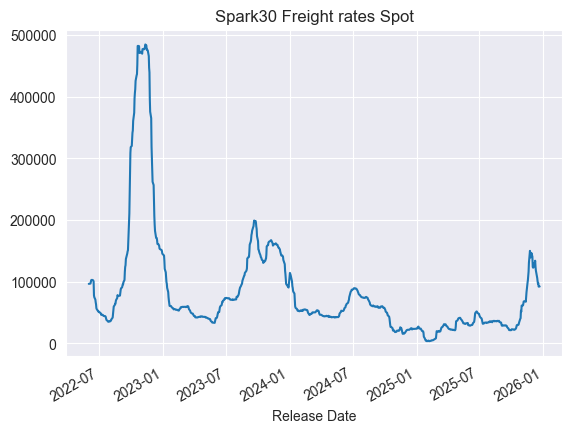

In [27]:
df = spark30_174.copy()
df.set_index("Release Date", inplace=True)
df["USDperday"].plot(title="Spark30 Freight rates Spot")
df

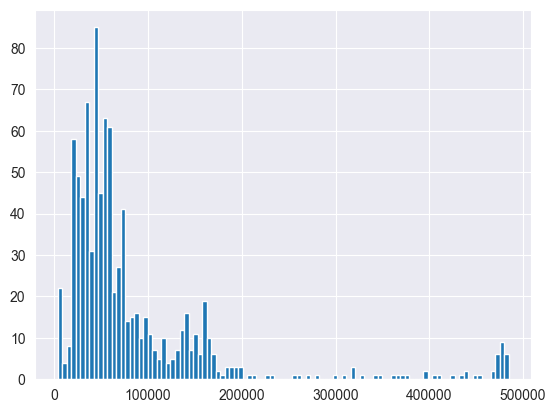

In [30]:
import matplotlib.pyplot as plt
plt.hist(df["USDperday"], label="Spark30 Freight rates Spot", bins=100);

37618.66219252922


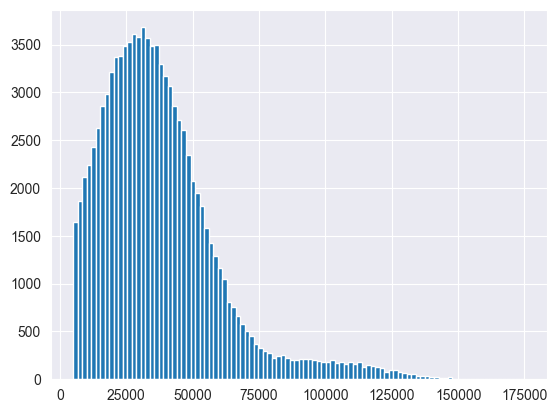

In [29]:
from BGN_LNG.Utils.utils_maths import truncated_normal_sample, jump_rv

n = 100000
bnwe = truncated_normal_sample(n, 5000, 100000, 30000, sigma=20000)
jump = jump_rv(n, p=0.05, mu=70000, sigma=5000)

x = bnwe + jump
print(x.mean())
plt.hist(x, bins=100);

In [7]:
from Utils.utils_spark import fetch_ffa_prices

my_dict = fetch_ffa_prices(access_token, "spark30ffa-monthly", 2, latest_only=True)

# my_dict = fetch_latest_price_releases(access_token, "spark30ffa-monthly")


ModuleNotFoundError: No module named 'Utils'

In [29]:
from BGN_LNG.Utils.utils_spark import fetch_ffa_prices_for_month_only
import numpy as np
month_tenor = "Apr-2026"
dict_freight_std_by_month = {}
for month_tenor in ["Oct-2026", "Nov-2026", "Dec-2026",
                    "Jan-2027", "Feb-2027", "Mar-2027","Apr-2027","May-2027","Jun-2027","Jul-2027","Aug-2027","Sep-2027","Oct-2027","Nov-2027","Dec-2027"]:
    df_month = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 30*30, month_tenor)
    logreturns = np.log(df_month.Spark / df_month.Spark.shift(-1)).dropna()
    std_month = logreturns.std()*np.sqrt(252)
    dict_freight_std_by_month[month_tenor] = std_month

print(dict_freight_std_by_month)

spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
spark30ffa-monthly
/v1.0/contracts/spark30ffa-monthly/price-releases/?limit=900
Fetching h

In [30]:
dict_freight_std_by_month

{'Oct-2026': np.float64(0.3407460632950163),
 'Nov-2026': np.float64(0.3268182706884584),
 'Dec-2026': np.float64(0.30697299980150616),
 'Jan': np.float64(nan),
 'Feb-2027': np.float64(0.2076285431417751),
 'Mar-2027': np.float64(0.20887022098735772),
 'Apr-2027': np.float64(0.14264022229872317),
 'May-2027': np.float64(0.1102957534590615),
 'Jun-2027': np.float64(0.1027438375416756),
 'Jul-2027': np.float64(0.09099747250955789),
 'Aug-2027': np.float64(0.09371509630357142),
 'Sep-2027': np.float64(0.08324955574611086),
 'Oct-2027': np.float64(0.09458501155124971),
 'Nov-2027': np.float64(0.1474933390229588),
 'Dec-2027': np.float64(0.16603488041880596)}

In [26]:
import numpy as np
logreturns = np.log(df_month.Spark / df_month.Spark.shift(-1)).dropna()
logreturns

0      0.000000
1      0.000000
2     -0.010152
3      0.000000
4      0.000000
         ...   
264   -0.006515
265    0.000000
266    0.000000
267   -0.031952
268    0.012658
Name: Spark, Length: 269, dtype: float64

In [28]:
logreturns.std()*np.sqrt(252)

np.float64(0.3626964471386627)